# BPY518 Lecture 3: Image Transformations and Fourier Transforms
Instructor: Josh Shaevitz  
Email: shaevitz@princeton.edu

## Lecture Outline
- Fourier transforms and spatial frequency
- Low-pass and high-pass filtering
- Affine transformations
- Cropping and resizing
- Decimation and interpolation

In Lecture 31 we started treating images as arrays. In Lecture 32 we cleaned those arrays with denoising and background subtraction. This lecture adds two new ideas:

1. The same image can be described in **real space** or in **frequency space**.
2. We can transform image coordinates with translations, rotations, scalings, shears, crops, and interpolation.

The PowerPoint deck starts with a short Fourier-transform review and then moves to spatial transformations, so this notebook follows that same flow.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage, interpolate

plt.rcParams['figure.dpi'] = 120
plt.rcParams['image.cmap'] = 'gray'

media_dir = Path('media/Lecture_3')

## A Short Fourier Transform Review

A Fourier transform rewrites a signal as a sum of sinusoids with different frequencies. For images, those frequencies describe how rapidly intensity changes across space.

- **Low spatial frequencies** correspond to smooth, slowly varying structure.
- **High spatial frequencies** correspond to sharp edges, fine texture, and rapid oscillations.

In one dimension, this is easiest to see by adding together a slow wave and a faster wave.

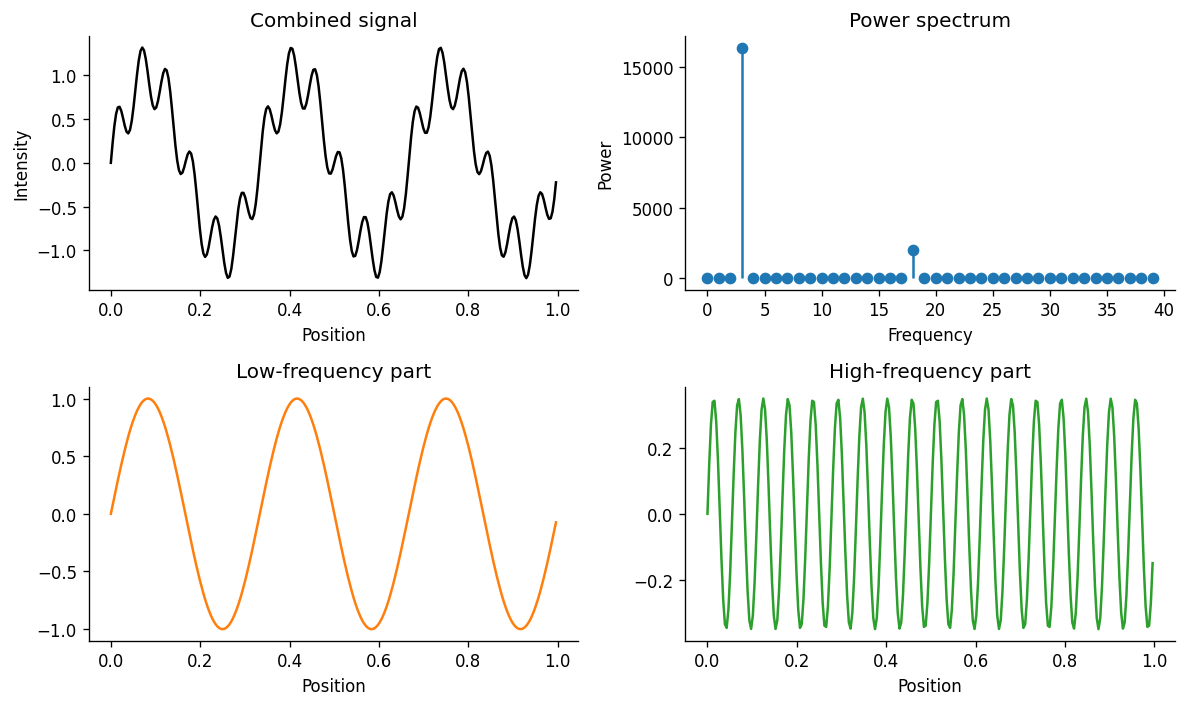

In [2]:
# Build a 1D signal from low- and high-frequency components.
x = np.linspace(0, 1, 256, endpoint=False)
low_component = np.sin(2 * np.pi * 3 * x)
high_component = 0.35 * np.sin(2 * np.pi * 18 * x)
signal = low_component + high_component

fft_signal = np.fft.fft(signal)
frequencies = np.fft.fftfreq(signal.size, d=x[1] - x[0])
power = np.abs(fft_signal) ** 2

low_mask = np.abs(frequencies) <= 6
high_mask = np.abs(frequencies) >= 10
low_reconstruction = np.fft.ifft(fft_signal * low_mask).real
high_reconstruction = np.fft.ifft(fft_signal * high_mask).real

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes[0, 0].plot(x, signal, color='black')
axes[0, 0].set_title('Combined signal')
axes[0, 0].set_xlabel('Position')
axes[0, 0].set_ylabel('Intensity')

axes[0, 1].stem(frequencies[:40], power[:40], basefmt=' ', linefmt='C0-', markerfmt='C0o')
axes[0, 1].set_title('Power spectrum')
axes[0, 1].set_xlabel('Frequency')
axes[0, 1].set_ylabel('Power')

axes[1, 0].plot(x, low_reconstruction, color='C1')
axes[1, 0].set_title('Low-frequency part')
axes[1, 0].set_xlabel('Position')

axes[1, 1].plot(x, high_reconstruction, color='C2')
axes[1, 1].set_title('High-frequency part')
axes[1, 1].set_xlabel('Position')

for ax in axes.flat:
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()

## Low-Pass and High-Pass Filtering

A **low-pass filter** keeps slow intensity variations and suppresses rapid ones. In real images, that usually means smoothing or blurring.

A **high-pass filter** does the opposite: it removes the slowly varying background and keeps fast changes such as edges and fine detail.

The source slide deck illustrates the idea with simple stripe patterns:

![Frequency examples](media/Lecture_3/frequency_patterns.png)

The left side has broad, slowly varying structure. The right side has rapid oscillations, so it contains more high-frequency content.

## The Fourier Transform of a Microscopy Image

For a 2D image, the Fourier transform becomes a 2D map of spatial frequencies. Large bright features near the center correspond to low frequencies. Farther from the center, we see higher frequencies.

We will use one of the microscopy examples embedded in the PowerPoint deck and compute the transform directly in Python.

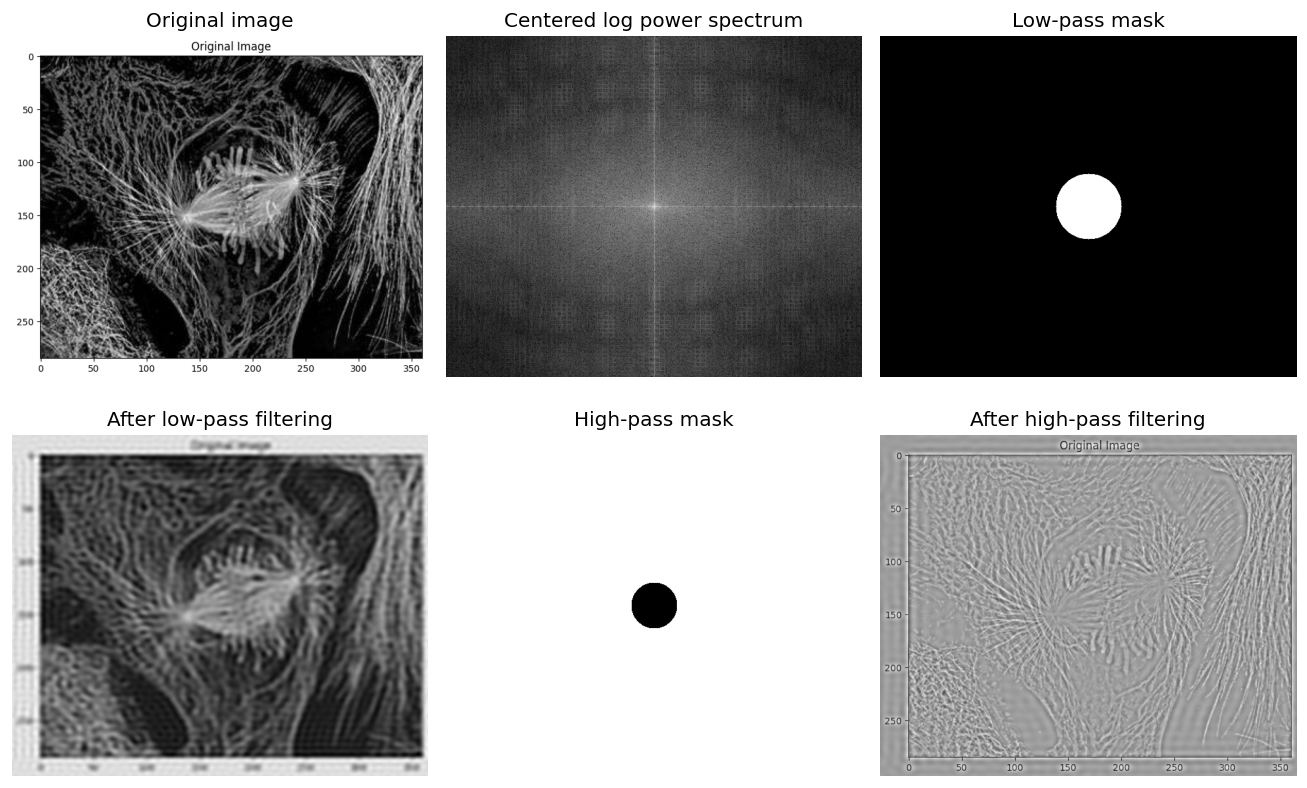

In [3]:
# Load the microscopy example from the source deck.
microscopy = plt.imread(media_dir / 'microscopy_example.png')
if microscopy.ndim == 3:
    microscopy = microscopy[..., 0]
microscopy = microscopy.astype(float)
if microscopy.max() > 1:
    microscopy /= microscopy.max()

fft2 = np.fft.fftshift(np.fft.fft2(microscopy))
power_spectrum = np.log1p(np.abs(fft2))

rows, cols = microscopy.shape
yy, xx = np.ogrid[:rows, :cols]
cy, cx = rows // 2, cols // 2
radius = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)

low_pass_mask = radius <= 50
high_pass_mask = radius >= 35

low_pass_image = np.fft.ifft2(np.fft.ifftshift(fft2 * low_pass_mask)).real
high_pass_image = np.fft.ifft2(np.fft.ifftshift(fft2 * high_pass_mask)).real

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
axes[0, 0].imshow(microscopy)
axes[0, 0].set_title('Original image')
axes[0, 1].imshow(power_spectrum)
axes[0, 1].set_title('Centered log power spectrum')
axes[0, 2].imshow(low_pass_mask)
axes[0, 2].set_title('Low-pass mask')

axes[1, 0].imshow(low_pass_image)
axes[1, 0].set_title('After low-pass filtering')
axes[1, 1].imshow(high_pass_mask)
axes[1, 1].set_title('High-pass mask')
axes[1, 2].imshow(high_pass_image)
axes[1, 2].set_title('After high-pass filtering')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()

The exact cutoff radius matters: a tighter low-pass mask keeps only the coarsest structure, while a more aggressive high-pass mask emphasizes edges and can also amplify noise. This is the same tradeoff we saw in Lecture 32 when smoothing images in real space.

## Affine Transformations

An affine transformation changes image coordinates using a linear map plus a translation:

$$
\begin{bmatrix}x' \\ y'\end{bmatrix} =
\mathbf{A}\begin{bmatrix}x \\ y\end{bmatrix} + \mathbf{t}
$$

Depending on the matrix $\mathbf{A}$, this can produce rotations, scalings, shears, or combinations of them. The translation vector $\mathbf{t}$ shifts the image afterward.

![Affine schematic](media/Lecture_3/affine_schematic.png)

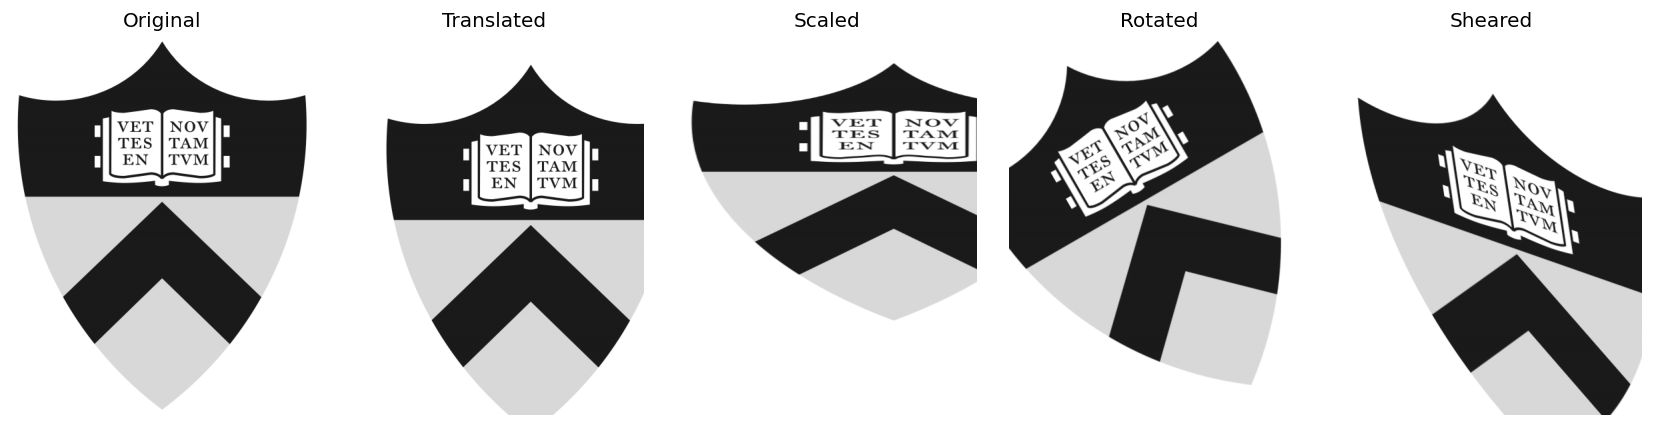

In [4]:
# Use the PowerPoint shield image as a test object for geometric transforms.
shield = plt.imread(media_dir / 'shield_source.png')
if shield.ndim == 3:
    shield = shield[..., 0]
shield = shield.astype(float)
if shield.max() > 1:
    shield /= shield.max()

def place_on_canvas(image, output_shape, top_left=(0, 0), fill_value=1.0):
    canvas = np.full(output_shape, fill_value, dtype=float)
    r0, c0 = top_left
    r1 = min(output_shape[0], r0 + image.shape[0])
    c1 = min(output_shape[1], c0 + image.shape[1])
    canvas[r0:r1, c0:c1] = image[: r1 - r0, : c1 - c0]
    return canvas

translated = ndimage.shift(shield, shift=(35, 55), order=1, mode='constant', cval=1.0)

scaled_small = ndimage.zoom(shield, zoom=(0.7, 1.4), order=1)
scaled = place_on_canvas(scaled_small, shield.shape, top_left=(35, 10))

rotated = ndimage.rotate(shield, angle=30, reshape=False, order=1, mode='constant', cval=1.0)

shear_matrix = np.array([[1.0, 0.35], [0.15, 1.0]])
inverse_shear = np.linalg.inv(shear_matrix)
sheared = ndimage.affine_transform(
    shield,
    inverse_shear,
    output_shape=shield.shape,
    order=1,
    mode='constant',
    cval=1.0,
)

fig, axes = plt.subplots(1, 5, figsize=(14, 3.5))
examples = [
    ('Original', shield),
    ('Translated', translated),
    ('Scaled', scaled),
    ('Rotated', rotated),
    ('Sheared', sheared),
]
for ax, (title, image) in zip(axes, examples):
    ax.imshow(image, vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()

The original slide deck implemented these examples with OpenCV's `warpAffine`. Here we use `scipy.ndimage` to demonstrate the same ideas while staying closer to the libraries already used in the course.

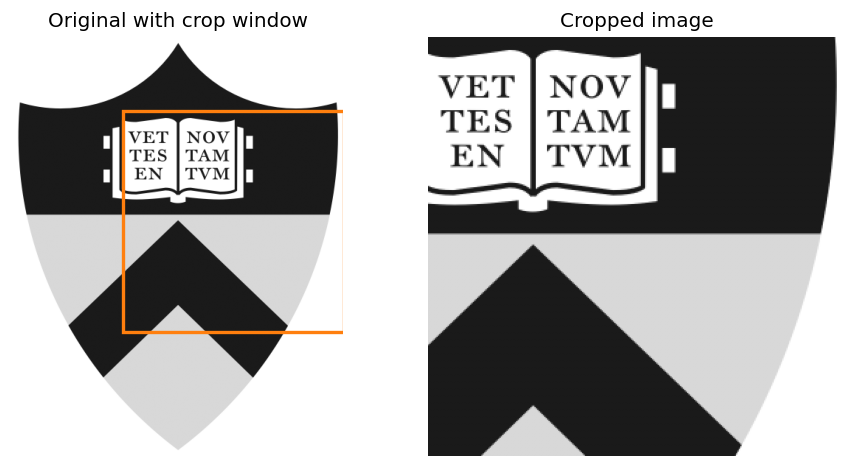

In [5]:
# Cropping is just array slicing.
x1, x2 = 150, 450
y1, y2 = 100, 400
cropped_shield = shield[y1:y2, x1:x2]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(shield, vmin=0, vmax=1)
axes[0].add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor='C1', facecolor='none', linewidth=2))
axes[0].set_title('Original with crop window')
axes[0].axis('off')

axes[1].imshow(cropped_shield, vmin=0, vmax=1)
axes[1].set_title('Cropped image')
axes[1].axis('off')

plt.tight_layout()

## Image Resizing, Decimation, and Interpolation

Resizing changes the sampling grid of the image. Sometimes that is useful for memory, speed, or visualization, but it does **not** magically create new experimental information.

- **Decimation** keeps every $n$-th pixel and throws the rest away.
- **Interpolation** estimates intensity values at locations that were not originally sampled.

The slide deck emphasizes an important warning: interpolation can be useful, but it is still making up values between measured pixels.

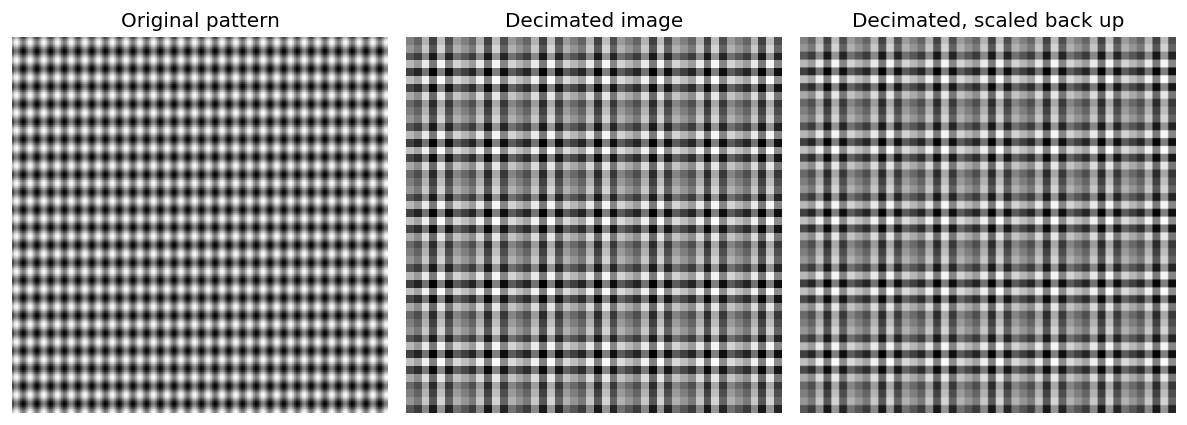

In [6]:
# Decimation can lose detail and create aliasing.
yy, xx = np.mgrid[:192, :192]
pattern = 0.5 + 0.25 * np.sin(2 * np.pi * xx / 7) + 0.25 * np.sin(2 * np.pi * yy / 9)
pattern = np.clip(pattern, 0, 1)

factor = 4
decimated = pattern[::factor, ::factor]
decimated_for_display = np.repeat(np.repeat(decimated, factor, axis=0), factor, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
axes[0].imshow(pattern, vmin=0, vmax=1)
axes[0].set_title('Original pattern')
axes[1].imshow(decimated, vmin=0, vmax=1)
axes[1].set_title('Decimated image')
axes[2].imshow(decimated_for_display, vmin=0, vmax=1)
axes[2].set_title('Decimated, scaled back up')

for ax in axes:
    ax.axis('off')

plt.tight_layout()

## Interpolation in 1D

Different interpolation rules produce different curves between the same data points. The PowerPoint deck contrasts nearest-neighbor, linear, and polynomial/spline interpolation:

![1D interpolation examples](media/Lecture_3/interpolation_1d_examples.png)

Higher-order interpolation can look smoother, but it can also overshoot or invent structure that was never measured.

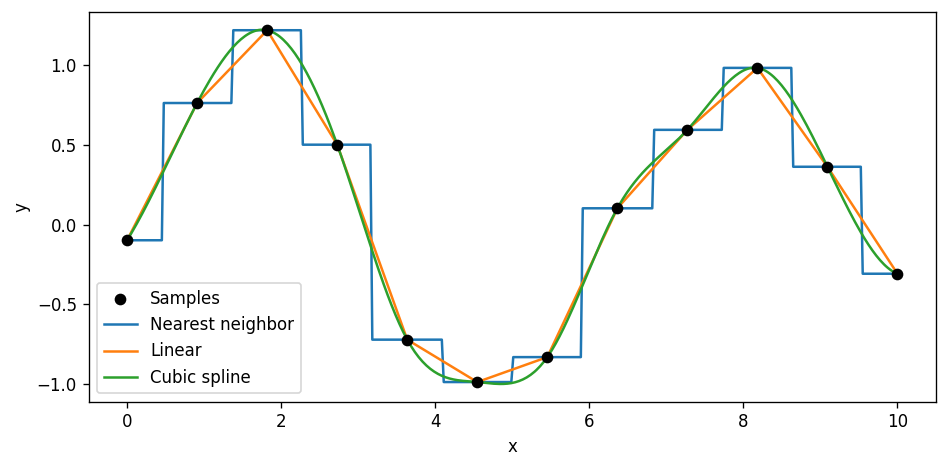

In [7]:
# Compare a few 1D interpolation strategies on noisy samples.
rng = np.random.default_rng(4)
x_coarse = np.linspace(0, 10, 12)
y_coarse = np.sin(x_coarse) + 0.15 * rng.normal(size=x_coarse.size)
x_dense = np.linspace(x_coarse.min(), x_coarse.max(), 400)

nearest = interpolate.interp1d(x_coarse, y_coarse, kind='nearest')
linear = interpolate.interp1d(x_coarse, y_coarse, kind='linear')
cubic = interpolate.interp1d(x_coarse, y_coarse, kind='cubic')

plt.figure(figsize=(8, 4))
plt.scatter(x_coarse, y_coarse, color='black', label='Samples', zorder=3)
plt.plot(x_dense, nearest(x_dense), label='Nearest neighbor')
plt.plot(x_dense, linear(x_dense), label='Linear')
plt.plot(x_dense, cubic(x_dense), label='Cubic spline')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()

## Interpolation in 2D

For images, interpolation happens in two dimensions. The simplest useful version is **bilinear interpolation**, which uses the four nearest pixel values around a point:

![2D interpolation schematic](media/Lecture_3/interpolation_2d_schematic.png)

If a point lies a fraction $a$ of the way across and a fraction $b$ of the way up a 2-by-2 neighborhood, then the bilinear estimate is

$$
I(x, y) = (1-a)(1-b)I_{00} + a(1-b)I_{10} + (1-a)bI_{01} + abI_{11}.
$$

Nearest-neighbor, bilinear, and bicubic interpolation all make different tradeoffs between speed, smoothness, and artifact suppression.

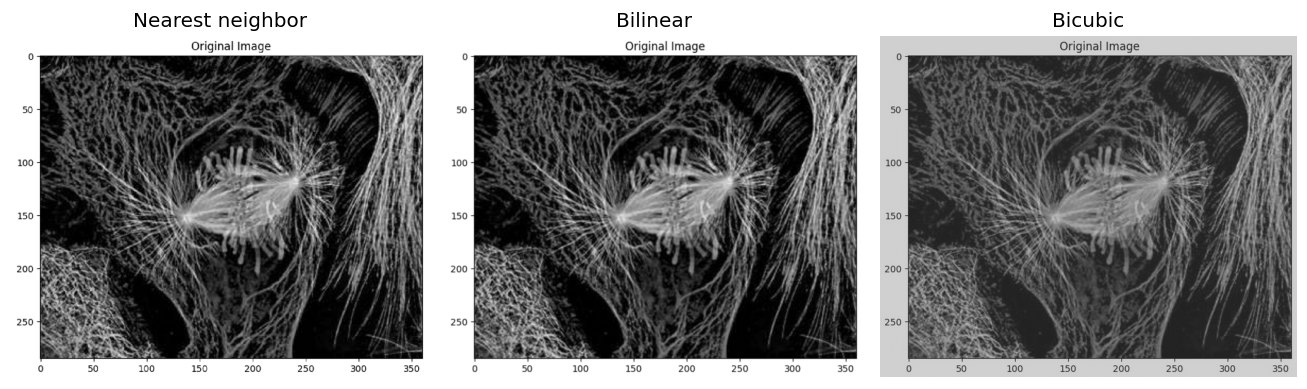

In [8]:
# Resize the microscopy image with different interpolation orders.
zoom_factor = 1.8
nearest_zoom = ndimage.zoom(microscopy, zoom_factor, order=0)
bilinear_zoom = ndimage.zoom(microscopy, zoom_factor, order=1)
bicubic_zoom = ndimage.zoom(microscopy, zoom_factor, order=3)

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, title, image in zip(axes, ['Nearest neighbor', 'Bilinear', 'Bicubic'], [nearest_zoom, bilinear_zoom, bicubic_zoom]):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()

## Key Points

- Fourier transforms describe images in terms of spatial frequency rather than pixel location.
- Low-pass filtering smooths images; high-pass filtering emphasizes rapid changes.
- Affine transformations change image coordinates through a matrix plus a translation.
- Cropping is just slicing an array.
- Resizing always depends on an interpolation rule, and that rule changes the visual result.